In [7]:
from src.workloads import Workloads
import configparser
import os
import re
import numpy as np
from src.utils import get_config_as_dict
import matplotlib.pyplot as plt
import csv

In [8]:
# Load config with explicit path and typed parsing
config = configparser.ConfigParser()
config_path = os.path.join(os.getcwd(), 'config_file', 'config.ini')
config.read(config_path)
config_dict = get_config_as_dict(config)


In [9]:
WORKLOAD_PATH = "./data/workloads/validation_workload.swf" 






In [23]:
import matplotlib.pyplot as plt
import re

def analyze_arrival_times(path):
    arrival_time = []

    with open(path) as fp:
        for line in fp:
            if line.startswith(";"):
                continue
            line = line.strip()
            s_array = re.split(r"\s+", line)
            
            # Append to standard Python lists
            arrival_time.append(int(s_array[1]))

    # Plot histogram
    plt.hist(arrival_time, bins=1000)

    # Add vertical lines every 24 hours (86400 sec)
    max_time = max(arrival_time)
    for t in range(0, max_time, 86400):
        plt.axvline(t, color='red', linestyle='--', alpha=0.7)

    plt.xlabel("Time (seconds)")
    plt.ylabel("Count")
    plt.title("Arrival Times with 24h markers")
    plt.show()


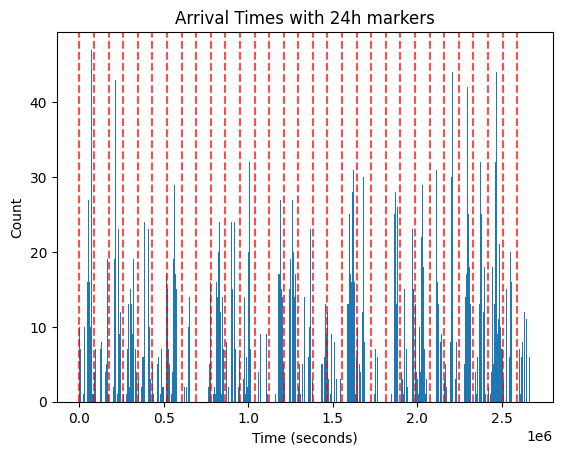

In [24]:
#analyze(WORKLOAD_PATH)
analyze_arrival_times(WORKLOAD_PATH)

In [ ]:
### Preprocess swf

def generate_training_swf(path):
    

In [ ]:

def transform_csv(input_filepath, output_filepath):
    """
    Transforms a CSV file from a wide format with years as columns to a long
    format with years integrated into the timestamp. The output is sorted
    chronologically by the full timestamp.

    Args:
        input_filepath (str): The path to the input CSV file.
        output_filepath (str): The path where the transformed CSV will be saved.
    """
    try:
        # Check if the input file exists
        if not os.path.exists(input_filepath):
            print(f"Error: Input file not found at '{input_filepath}'")
            return

        transformed_data = []

        with open(input_filepath, 'r', newline='') as infile:
            reader = csv.reader(infile)

            # Read the header row from the input file
            header = next(reader)
            time_column_name = header[0]
            year_columns = header[1:]

            # Iterate through each data row in the input file
            for row in reader:
                date_time_part = row[0]
                values = row[1:]

                # For each year, create a new data point
                for i, year in enumerate(year_columns):
                    # Combine the year with the date and time part
                    full_timestamp = f"{year}-{date_time_part}"
                    # Get the corresponding value
                    value = values[i]
                    # Add the new row to our data list
                    transformed_data.append([full_timestamp, value])
        
        # Sort the data chronologically based on the full timestamp
        transformed_data.sort(key=lambda x: x[0])

        with open(output_filepath, 'w', newline='') as outfile:
            writer = csv.writer(outfile)

            # Write the new header for the output file
            new_header_name = time_column_name.replace("MM-DD HH:MM:SS", "YYYY-MM-DD HH:MM:SS")
            writer.writerow([new_header_name, 'Value'])

            # Write the sorted data to the output file
            writer.writerows(transformed_data)

        print(f"Successfully transformed '{input_filepath}' and saved to '{output_filepath}'")

    except Exception as e:
        print(f"An error occurred: {e}")


Successfully transformed 'input_data.csv' and saved to 'output_data.csv'

--- Output File Content ---
YYYY-MM-DD HH:MM:SS (UTC),Value
2021-01-01 00:00:00,87.26
2021-01-01 00:01:00,87.1558
2021-01-01 00:02:00,87.0516
2022-01-01 00:00:00,119.31
2022-01-01 00:01:00,119.1028
2022-01-01 00:02:00,118.8956
2023-01-01 00:00:00,53.1
2023-01-01 00:01:00,53.215
2023-01-01 00:02:00,53.33
2024-01-01 00:00:00,123.04
2024-01-01 00:01:00,122.9708
2024-01-01 00:02:00,122.9016

--------------------------


In [ ]:
input = "data/DK-DK2_minutely_carbon_intensity.csv"
output = "data/DK-DK2_minutely_carbon_intensity_improved.csv"
transform_csv(input_filepath=input, output_filepath=output)

Successfully transformed 'data/DK-DK2_minutely_carbon_intensity.csv' and saved to 'data/DK-DK2_minutely_carbon_intensity_improved.csv'
